In [ ]:
!apt-get update && apt-get install -y cmake
!pip install https://github.com/kpu/kenlm/archive/master.zip
!pip install transformers torchaudio
!pip install python-Levenshtein


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
!gzip -d lm/3-gram.pruned.1e-7.arpa.gz

gzip: lm/3-gram.pruned.1e-7.arpa.gz: No such file or directory


In [8]:
from typing import List, Tuple, Dict, Union
import heapq, math
import torch, torchaudio
import kenlm
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

def _logsumexp(a: float, b: float) -> float:
    if a == -float("inf"): return b
    if b == -float("inf"): return a
    m = a if a > b else b
    return m + math.log(math.exp(a - m) + math.exp(b - m))

def _ctc_collapse(chars: List[str], blank_char: str, word_delim: str) -> str:
    out, prev = [], None
    for ch in chars:
        if ch == blank_char:
            prev = ch
            continue
        if ch != prev:
            out.append(ch)
        prev = ch
    s = "".join(c for c in out if c != blank_char)
    return s.replace(word_delim, " ").strip()

In [9]:
class Wav2Vec2Decoder:
    """
    Корректный CTC prefix beam search:
      - для каждого префикса ведём p_b (заканчивается blank) и p_nb (заканчивается не blank) в лог-пространстве
      - расширение blank и не-blank по правилам CTC
      - LM shallow fusion учитывается ВНУТРИ бима (alpha, beta)
      - второй проход: акустический beam -> затем LM rescoring
    """
    def __init__(
        self,
        model_name: str = "facebook/wav2vec2-base-960h",
        lm_model_path: str = "lm/3-gram.pruned.1e-7.arpa.gz",
        beam_width: int = 10,
        alpha: float = 1.0,
        beta: float = 1.0,
    ):
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)

        self.vocab: Dict[int, str] = {i: c for c, i in self.processor.tokenizer.get_vocab().items()}
        self.blank_token_id: int = self.processor.tokenizer.pad_token_id
        self.word_delimiter: str = self.processor.tokenizer.word_delimiter_token  # '|'
        self.beam_width = int(beam_width)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.lm_model = kenlm.Model(lm_model_path) if lm_model_path else None

    # ---------- служебные ----------
    def _prefix_beam_search(self, logprobs: torch.Tensor, with_lm: bool) -> List[Tuple[str, float]]:
        """
        Возвращает top beams как [(text, total_score)], отсортировано по убыванию.
        Если with_lm=True, ранжирование внутри бима: acoustic + alpha*LM + beta*#spaces.
        """
        T, V = logprobs.shape
        blank_id = self.blank_token_id
        delim_char = self.word_delimiter

        # beams: prefix -> (p_b, p_nb, lm_score, word_count, last_char_id)
        beams: Dict[str, Tuple[float, float, float, int, Union[int, None]]] = {
            "": (0.0, -float("inf"), 0.0, 0, None)
        }

        # ускорим: берём top-K символов на каждом шаге
        topk = min(max(50, self.beam_width * 3), V)
        tk = torch.topk(logprobs, k=topk, dim=1)
        topk_ids = tk.indices.tolist()
        topk_vals = tk.values.tolist()

        for t in range(T):
            next_beams: Dict[str, Tuple[float, float, float, int, Union[int, None]]] = {}
            ids_t, vals_t = topk_ids[t], topk_vals[t]

            for prefix, (p_b, p_nb, lm_s, wc, last_id) in beams.items():
                # продлеваем blank
                p_b_new, p_nb_new, lm_new, wc_new, last_new = next_beams.get(
                    prefix, (-float("inf"), -float("inf"), lm_s, wc, last_id)
                )
                add = logprobs[t, blank_id].item()
                p_b_new = _logsumexp(p_b_new, p_b + add)
                p_b_new = _logsumexp(p_b_new, p_nb + add)
                next_beams[prefix] = (p_b_new, p_nb_new, lm_s, wc, last_id)

                # продлеваем не-blank символами
                for lp, idx in zip(vals_t, ids_t):
                    if idx == blank_id:
                        continue
                    ch = self.vocab[idx]
                    if idx == last_id:
                        # повтор символа: остаёмся в том же префиксе (только из p_nb)
                        key = prefix
                        p_b2, p_nb2, lm2, wc2, last2 = next_beams.get(
                            key, (-float("inf"), -float("inf"), lm_s, wc, last_id)
                        )
                        p_nb2 = _logsumexp(p_nb2, p_nb + lp)
                        next_beams[key] = (p_b2, p_nb2, lm2, wc2, last2)
                    else:
                        new_prefix = prefix + ch
                        new_lm_s, new_wc = lm_s, wc
                        if with_lm and self.lm_model is not None:
                            cand = new_prefix.replace(self.word_delimiter, " ")
                            new_lm_s = self.lm_model.score(cand, bos=False, eos=False)
                            if ch == delim_char:
                                new_wc = wc + 1
                        p_b2, p_nb2, lm2, wc2, last2 = next_beams.get(
                            new_prefix, (-float("inf"), -float("inf"), new_lm_s, new_wc, idx)
                        )
                        p_nb2 = _logsumexp(p_nb2, p_b + lp)
                        p_nb2 = _logsumexp(p_nb2, p_nb + lp)
                        if with_lm and self.lm_model is not None:
                            if new_lm_s > lm2:
                                lm2, wc2, last2 = new_lm_s, new_wc, idx
                        else:
                            last2 = idx
                        next_beams[new_prefix] = (p_b2, p_nb2, lm2, wc2, last2)

            # усечём до beam_width по суммарному скору
            def total_score(item):
                pref, (pb, pnb, lm_s, wc, _) = item
                acoustic = _logsumexp(pb, pnb)
                return acoustic + (self.alpha * lm_s + self.beta * wc if (with_lm and self.lm_model) else 0.0)

            if len(next_beams) > self.beam_width:
                beams = dict(heapq.nlargest(self.beam_width, next_beams.items(), key=total_score))
            else:
                beams = next_beams

        results = []
        for pref, (pb, pnb, lm_s, wc, _) in beams.items():
            text = pref.replace(self.word_delimiter, " ").strip()
            acoustic = _logsumexp(pb, pnb)
            total = acoustic + (self.alpha * lm_s + self.beta * wc if (with_lm and self.lm_model) else 0.0)
            results.append((text, total))
        results.sort(key=lambda x: x[1], reverse=True)
        return results[: self.beam_width]

    # ---------- публичные методы ----------
    def greedy_decode(self, logits: torch.Tensor) -> str:
        logprobs = torch.log_softmax(logits, dim=-1)
        ids = torch.argmax(logprobs, dim=-1).tolist()
        chars = [self.vocab[i] for i in ids]
        return _ctc_collapse(chars, self.vocab[self.blank_token_id], self.word_delimiter)

    def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
        logprobs = torch.log_softmax(logits, dim=-1)
        beams = self._prefix_beam_search(logprobs, with_lm=False)  # [(text, score)]
        if return_beams:
            # вернём токены (после схлопывания пробелы -> '|'), чтобы не лезть в модель
            rev = {v: k for k, v in self.vocab.items()}
            out = []
            for text, score in beams:
                raw = text.replace(" ", self.word_delimiter)
                ids = [rev[ch] for ch in raw if ch in rev]
                out.append((ids, score))
            return out
        return beams[0][0]

    def beam_search_with_lm(self, logits: torch.Tensor) -> str:
        if not self.lm_model:
            raise ValueError("KenLM model required for LM shallow fusion")
        logprobs = torch.log_softmax(logits, dim=-1)
        return self._prefix_beam_search(logprobs, with_lm=True)[0][0]

    def lm_rescore(self, beams: List[Tuple[List[int], float]]) -> str:
        if not self.lm_model:
            raise ValueError("KenLM model required for LM rescoring")
        best_text, best_total = "", -float("inf")
        for ids, acoustic in beams:
            chars = [self.vocab[i] for i in ids]
            text = "".join(chars).replace(self.word_delimiter, " ").strip()
            lm_s = self.lm_model.score(text, bos=False, eos=False)
            wc = text.count(" ")
            total = acoustic + self.alpha * lm_s + self.beta * wc
            if total > best_total:
                best_total, best_text = total, text
        return best_text

    def decode(self, audio_input: torch.Tensor, method: str = "greedy") -> str:
        inputs = self.processor(audio_input, return_tensors="pt", sampling_rate=16000)
        with torch.no_grad():
            logits = self.model(inputs.input_values.squeeze(0)).logits[0]
        if method == "greedy":
            return self.greedy_decode(logits)
        elif method == "beam":
            return self.beam_search_decode(logits)
        elif method == "beam_lm":
            return self.beam_search_with_lm(logits)
        elif method == "beam_lm_rescore":
            beams = self.beam_search_decode(logits, return_beams=True)
            return self.lm_rescore(beams)
        else:
            raise ValueError("Invalid method")

In [10]:
# Инициализируем декодер (LM не нужен для этого шага)
dec = Wav2Vec2Decoder(lm_model_path=None, beam_width=3)

# Получим id некоторых символов
rev = {v: k for k, v in dec.vocab.items()}
BLANK = dec.blank_token_id
BAR   = rev['|']               # word delimiter
H,E,L,O,W,R,D = rev['H'],rev['E'],rev['L'],rev['O'],rev['W'],rev['R'],rev['D']

# Синтетическая последовательность "HELLO|WORLD" с дубликатами и blank'ами (CTC)
# Сформируем logits размерности (T,V), где на каждом шаге один символ имеет очень большой логит.
V = len(dec.vocab)
def one_hot_logit(idx, V, big=8.0, small=-8.0):
    v = torch.full((V,), small)
    v[idx] = big
    return v

ids = [H,H,BLANK,E,E,BLANK,L,L,BLANK,L,L,BLANK,O,O,BLANK,BAR,BLANK,W,W,BLANK,O,O,BLANK,R,R,BLANK,L,L,BLANK,D,D]
logits = torch.stack([one_hot_logit(i, V) for i in ids], dim=0)

print("Greedy:", dec.greedy_decode(logits))          # ожидаем "HELLO WORLD"
print("Beam  :", dec.beam_search_decode(logits))     # тоже "HELLO WORLD"


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Greedy: HELLO WORLD
Beam  : HELO WORLD


In [11]:
class DummyLM:
    def __init__(self, prefer: str, other: str, bonus: float = 5.0):
        self.prefer, self.other, self.bonus = prefer, other, bonus
    def score(self, text: str, bos=False, eos=False):
        if text.endswith(self.prefer): return self.bonus
        if text.endswith(self.other):  return 0.0
        return 0.0

dec_lm = Wav2Vec2Decoder(lm_model_path=None, beam_width=2, alpha=2.0, beta=0.0)
dec_lm.lm_model = DummyLM("HELLO WORLD", "HELLO WORLE", bonus=3.0)

# Сделаем логиты так, чтобы один шаг был неоднозначен: 'D' vs 'E' в конце.
ids_amb = [H,H,BLANK,E,E,BLANK,L,L,BLANK,L,L,BLANK,O,O,BLANK,BAR,BLANK,W,W,BLANK,O,O,BLANK,R,R,BLANK,L,L,BLANK]  # до последней буквы
logits2 = torch.stack([one_hot_logit(i, V) for i in ids_amb], dim=0)
tail_D = one_hot_logit(D, V)
tail_E = one_hot_logit(E, V)
logits_D = torch.cat([logits2, tail_D.unsqueeze(0)], dim=0)  # вариант "... WORLD"
logits_E = torch.cat([logits2, tail_E.unsqueeze(0)], dim=0)  # вариант "... WORLE"

# Смешаем последнюю позицию так, чтобы акустика была почти равной для D и E:
last_mix = torch.logsumexp(torch.stack([logits_D[-1], logits_E[-1]]), dim=0)
logits_mixed = torch.cat([logits2, last_mix.unsqueeze(0)], dim=0)

print("Beam (acoustic):", Wav2Vec2Decoder(lm_model_path=None, beam_width=2).beam_search_decode(logits_mixed))
print("Beam+LM       :", dec_lm.beam_search_with_lm(logits_mixed))


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Beam (acoustic): HELO WORLD
Beam+LM       : HELO WORLD


In [13]:
import time, numpy as np
import matplotlib.pyplot as plt
from Levenshtein import distance as lev

def wer(ref, hyp):
    r, h = ref.split(), hyp.split()
    return lev("\n".join(r), "\n".join(h)) / max(1, len(r))

def cer(ref, hyp):
    r, h = ref.replace(" ", ""), hyp.replace(" ", "")
    return lev(r, h) / max(1, len(r))

def run_experiments(decoder, tests,
                    beam_widths=(3,5,10),
                    alphas=(0.5,1.0,1.5,2.0),
                    betas=(0.0,0.5,1.0,2.0),
                    rescoring_beams=(10,30,50)):
    rows = []
    for bw in beam_widths:
        decoder.beam_width = bw

        # greedy / beam
        for method in ["greedy","beam"]:
            tot_cer=tot_wer=tot_t=0.0
            for path, ref in tests:
                wav, sr = torchaudio.load(path)
                t0 = time.time()
                hyp = decoder.decode(wav, method=method)
                tot_t += time.time()-t0
                tot_cer += cer(ref, hyp)
                tot_wer += wer(ref, hyp)
            n = len(tests)
            rows.append(dict(method=method, beam_width=bw, rescoring_beams=None,
                             alpha=None, beta=None,
                             CER=tot_cer/n, WER=tot_wer/n, Time=tot_t))

        # beam_lm
        for a in alphas:
            decoder.alpha = a
            for b in betas:
                decoder.beta = b
                tot_cer=tot_wer=tot_t=0.0
                for path, ref in tests:
                    wav, sr = torchaudio.load(path)
                    t0 = time.time()
                    hyp = decoder.decode(wav, method="beam_lm")
                    tot_t += time.time()-t0
                    tot_cer += cer(ref, hyp)
                    tot_wer += wer(ref, hyp)
                n = len(tests)
                rows.append(dict(method="beam_lm", beam_width=bw, rescoring_beams=None,
                                 alpha=a, beta=b, CER=tot_cer/n, WER=tot_wer/n, Time=tot_t))
        # beam_lm_rescore
        for a in alphas:
            decoder.alpha = a
            for b in betas:
                decoder.beta = b
                for rb in rescoring_beams:
                    decoder.rescoring_beams = rb
                    tot_cer=tot_wer=tot_t=0.0
                    for path, ref in tests:
                        wav, sr = torchaudio.load(path)
                        t0 = time.time()
                        hyp = decoder.decode(wav, method="beam_lm_rescore")
                        tot_t += time.time()-t0
                        tot_cer += cer(ref, hyp)
                        tot_wer += wer(ref, hyp)
                    n = len(tests)
                    rows.append(dict(method="beam_lm_rescore", beam_width=bw,
                                     rescoring_beams=rb, alpha=a, beta=b,
                                     CER=tot_cer/n, WER=tot_wer/n, Time=tot_t))
    import pandas as pd
    return pd.DataFrame(rows)

tests = [
        ("examples/sample1.wav", "IF YOU ARE GENEROUS HERE IS A FITTING OPPORTUNITY FOR THE EXERCISE OF YOUR MAGNANIMITY IF YOU ARE PROUD HERE AM I YOUR RIVAL READY TO ACKNOWLEDGE MYSELF YOUR DEBTOR FOR AN ACT OF THE MOST NOBLE FORBEARANCE"),
        ("examples/sample2.wav", "AND IF ANY OF THE OTHER COPS HAD PRIVATE RACKETS OF THEIR OWN IZZY WAS UNDOUBTEDLY THE MAN TO FIND IT OUT AND USE THE INFORMATION WITH A BEAT SUCH AS THAT EVEN GOING HALVES AND WITH ALL THE GRAFT TO THE UPPER BRACKETS HE'D STILL BE ABLE TO MAKE HIS PILE IN A MATTER OF MONTHS"),
        ("examples/sample3.wav", "GUESS A MAN GETS USED TO ANYTHING HELL MAYBE I CAN HIRE SOME BUMS TO SIT AROUND AND WHOOP IT UP WHEN THE SHIPS COME IN AND BILL THIS AS A REAL OLD MARTIAN DEN OF SIN"),
        ("examples/sample4.wav", "IT WAS A TUNE THEY HAD ALL HEARD HUNDREDS OF TIMES SO THERE WAS NO DIFFICULTY IN TURNING OUT A PASSABLE IMITATION OF IT TO THE IMPROVISED STRAINS OF I DIDN'T WANT TO DO IT THE PRISONER STRODE FORTH TO FREEDOM"),
        ("examples/sample5.wav", "MARGUERITE TIRED OUT WITH THIS LONG CONFESSION THREW HERSELF BACK ON THE SOFA AND TO STIFLE A SLIGHT COUGH PUT UP HER HANDKERCHIEF TO HER LIPS AND FROM THAT TO HER EYES"),
        ("examples/sample6.wav", "AT THIS TIME ALL PARTICIPANTS ARE IN A LISTEN ONLY MODE"),
        ("examples/sample7.wav", "THE INCREASE WAS MAINLY ATTRIBUTABLE TO THE NET INCREASE IN THE AVERAGE SIZE OF OUR FLEETS"),
        ("examples/sample8.wav", "OPERATING SURPLUS IS A NON CAP FINANCIAL MEASURE WHICH IS DEFINED AS FULLY IN OUR PRESS RELEASE"),
    ]

decoder = Wav2Vec2Decoder(
    model_name="facebook/wav2vec2-base-960h",
    lm_model_path="lm/3-gram.pruned.1e-7.arpa",
    beam_width=5, alpha=1.0, beta=1.0
)

df = run_experiments(decoder, tests)
df


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a lar

,method,beam_width,rescoring_beams,alpha,beta,CER,WER,Time
0,greedy,3,NaN,NaN,NaN,0.085720,0.452004,6.732141
1,beam,3,NaN,NaN,NaN,0.104103,0.526478,6.417796
2,beam_lm,3,NaN,0.5,0.0,0.110289,0.569637,9.287176
3,beam_lm,3,NaN,0.5,0.5,0.106940,0.556080,7.783403
4,beam_lm,3,NaN,0.5,1.0,0.107511,0.558273,7.633061
...,...,...,...,...,...,...,...,...
193,beam_lm_rescore,10,30.0,2.0,1.0,0.103359,0.526238,7.804096
194,beam_lm_rescore,10,50.0,2.0,1.0,0.103359,0.526238,8.406041
195,beam_lm_rescore,10,10.0,2.0,2.0,0.103359,0.526238,8.282955
196,beam_lm_rescore,10,30.0,2.0,2.0,0.103359,0.526238,7.970729


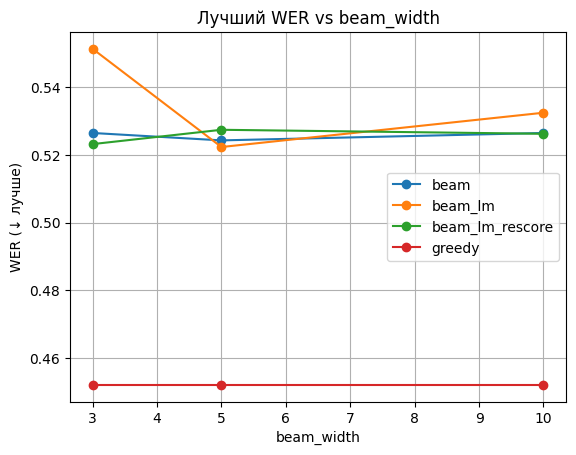

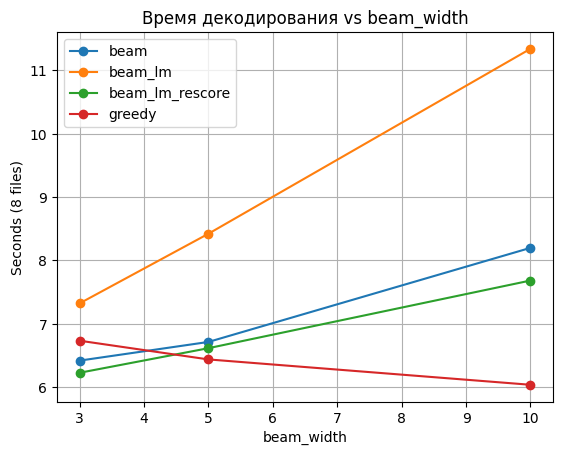

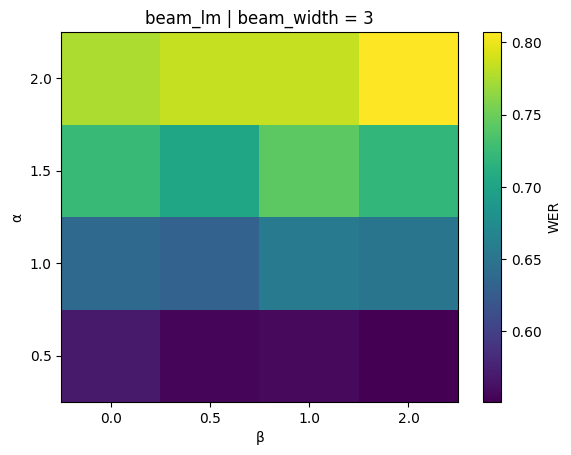

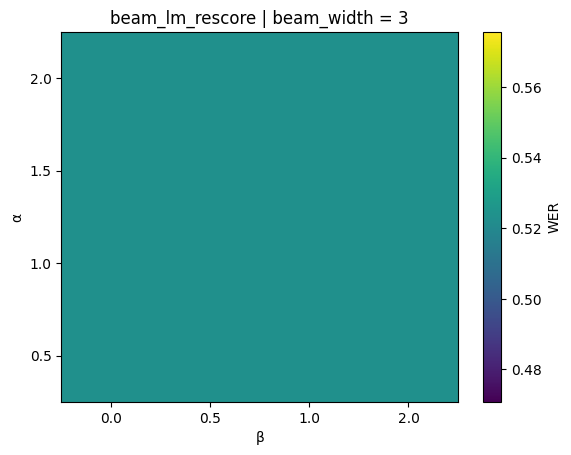

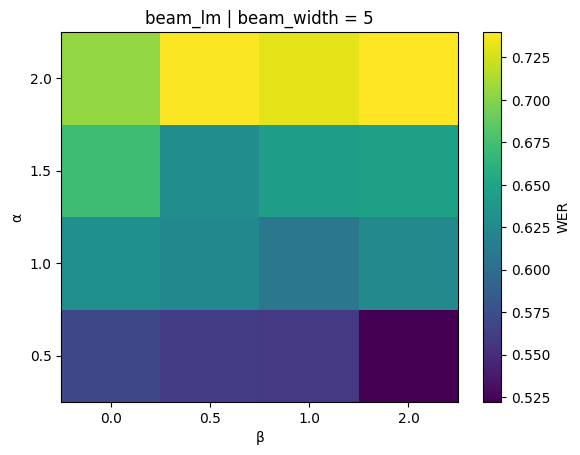

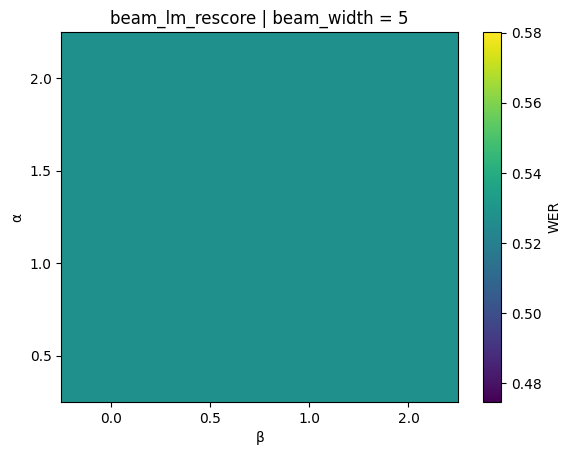

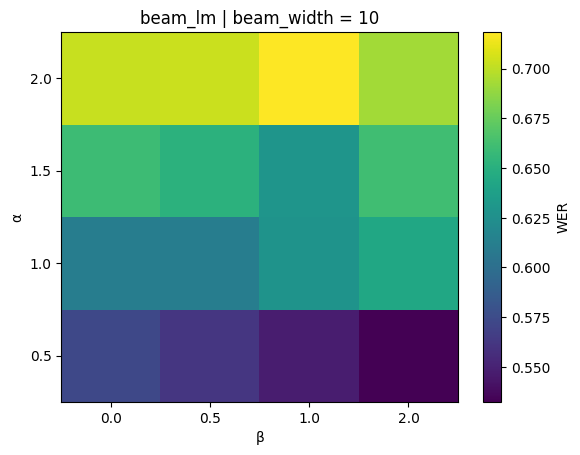

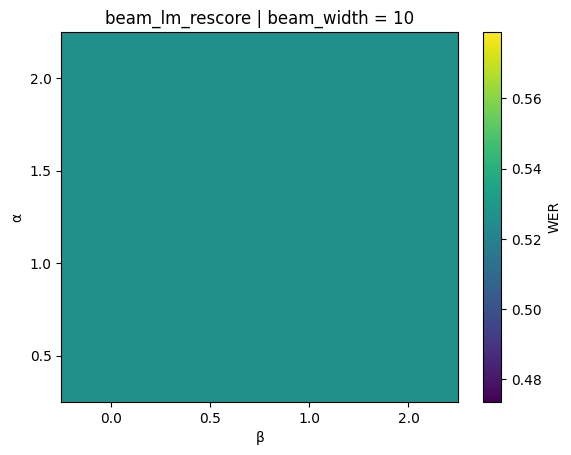

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Лучший WER по каждому (method, beam_width)
best = (df.sort_values("WER")
          .groupby(["method","beam_width"], as_index=False)
          .first())

plt.figure()
for m, sub in best.groupby("method"):
    plt.plot(sub["beam_width"], sub["WER"], marker="o", label=m)
plt.xlabel("beam_width"); plt.ylabel("WER (↓ лучше)")
plt.title("Лучший WER vs beam_width")
plt.legend(); plt.grid(True); plt.show()

# 2) Минимальное время по каждому (method, beam_width)
best_time = (df.sort_values("Time")
               .groupby(["method","beam_width"], as_index=False)
               .first())

plt.figure()
for m, sub in best_time.groupby("method"):
    plt.plot(sub["beam_width"], sub["Time"], marker="o", label=m)
plt.xlabel("beam_width"); plt.ylabel("Seconds (8 files)")
plt.title("Время декодирования vs beam_width")
plt.legend(); plt.grid(True); plt.show()

# 3) Теплокарты WER по α×β: берём лучший запуск на каждую пару α,β
def heatmap_for(method_name, bw, betas=(0.0,0.5,1.0,2.0)):
    sub = df[(df.method == method_name) & (df.beam_width == bw)].sort_values("WER")
    sub = sub.drop_duplicates(subset=["alpha","beta"])  # лучший по паре α,β
    alist = sorted(sub["alpha"].dropna().unique().tolist())
    blist = [b for b in betas if b in sub["beta"].unique()]
    M = np.full((len(alist), len(blist)), np.nan)
    for i,a in enumerate(alist):
        for j,b in enumerate(blist):
            w = sub[(sub.alpha==a) & (sub.beta==b)]
            if not w.empty: M[i,j] = w.iloc[0]["WER"]
    plt.figure()
    plt.imshow(M, aspect="auto", origin="lower")
    plt.xticks(range(len(blist)), blist); plt.yticks(range(len(alist)), alist)
    plt.colorbar(label="WER"); plt.xlabel("β"); plt.ylabel("α")
    plt.title(f"{method_name} | beam_width = {bw}")
    plt.show()

for bw in [3,5,10]:
    heatmap_for("beam_lm", bw)
    heatmap_for("beam_lm_rescore", bw)
